# 01 · Preparación de datos

**Proyecto:** EmoGol — Trabajo de grado, Universidad del Cauca  
**Autor:** Santiago Fernando Ortega Segura · **Director:** Ph.D. Oscar Mauricio Caicedo Rendón

Carga los 108.742 comentarios recolectados de YouTube, normaliza el texto y elimina duplicados (107.563 comentarios), hace el análisis exploratorio, fija la taxonomía de 7 emociones y separa una muestra de 600 comentarios para etiquetado manual. El resto forma el pool para el etiquetado automático.

*Nombre durante el desarrollo: `01_Preparacion_de_Datos` (algunas salidas conservan esa numeración).*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas pyarrow -q

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)

RUTA_DATASET_CRUDO = '/content/drive/MyDrive/RUTA/A/final_unified_dataset.json'
RUTA_SALIDA = '/content/drive/MyDrive/RUTA/A/data_prep'
Path(RUTA_SALIDA).mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


## 1. Carga del dataset crudo

In [ ]:
with open(RUTA_DATASET_CRUDO, 'r', encoding='utf-8') as f:
    data = json.load(f)

df_raw = pd.DataFrame(data)
print(f"Comentarios cargados: {len(df_raw):,}")
print(f"Columnas: {df_raw.columns.tolist()}")
df_raw.head(3)

Comentarios cargados: 108,742
Columnas: ['comment_id', 'source', 'event', 'video_id', 'author', 'created_at', 'likes', 'reply_count', 'text']


,comment_id,source,event,video_id,author,created_at,likes,reply_count,text
0,UgytsFkSxfPrWx6_y0V4AaABAg,youtube,youtube_match_event,EBXRDkM7vrM,@usuario,2026-05-07T02:49:53Z,0,0,Estos diablitos estan como para champions !!
1,Ugwt9pVKB66xrGIzdZt4AaABAg,youtube,youtube_match_event,EBXRDkM7vrM,@usuario,2026-05-06T21:30:30Z,1,0,Un tiro de esquina es como un corner. -PuerroV...
2,UgxDHqsWGhO6Y3T5sut4AaABAg,youtube,youtube_match_event,EBXRDkM7vrM,@usuario,2026-05-06T18:57:49Z,0,0,Porque ya no ponen los nombres de los jugadore...


### 1.1 Validación básica

In [ ]:
print("Valores nulos por columna:")
print(df_raw.isnull().sum())

print("\nDuplicados por comment_id:", df_raw['comment_id'].duplicated().sum())
print("Duplicados por texto exacto:", df_raw['text'].duplicated().sum())

df_raw['created_at'] = pd.to_datetime(df_raw['created_at'], errors='coerce')
print("\nRango de fechas:", df_raw['created_at'].min(), "→", df_raw['created_at'].max())
print("Videos distintos:", df_raw['video_id'].nunique())

Valores nulos por columna:
comment_id     0
source         0
event          0
video_id       0
author         0
created_at     0
likes          0
reply_count    0
text           0
dtype: int64

Duplicados por comment_id: 0
Duplicados por texto exacto: 1155

Rango de fechas: 2022-08-16 22:06:13+00:00 → 2026-05-12 19:50:32+00:00
Videos distintos: 178


## 2. Limpieza y normalización

In [ ]:
df_clean = df_raw.copy()
df_clean['text'] = df_clean['text'].astype(str).str.strip()
df_clean['text'] = df_clean['text'].str.replace(r'\s+', ' ', regex=True)
df_clean = df_clean[df_clean['text'].str.len() > 0].copy()

antes = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['text'], keep='first').copy()
print(f"Eliminados por duplicado de texto: {antes - len(df_clean)}")
print(f"Dataset limpio: {len(df_clean):,} comentarios (de {len(df_raw):,} originales)")

Eliminados por duplicado de texto: 1179
Dataset limpio: 107,563 comentarios (de 108,742 originales)


## 3. Análisis exploratorio (EDA)

count    107563.000000
mean         77.299583
std          82.912108
min           3.000000
25%          33.000000
50%          56.000000
75%          94.000000
max        8223.000000
Name: text_length, dtype: float64


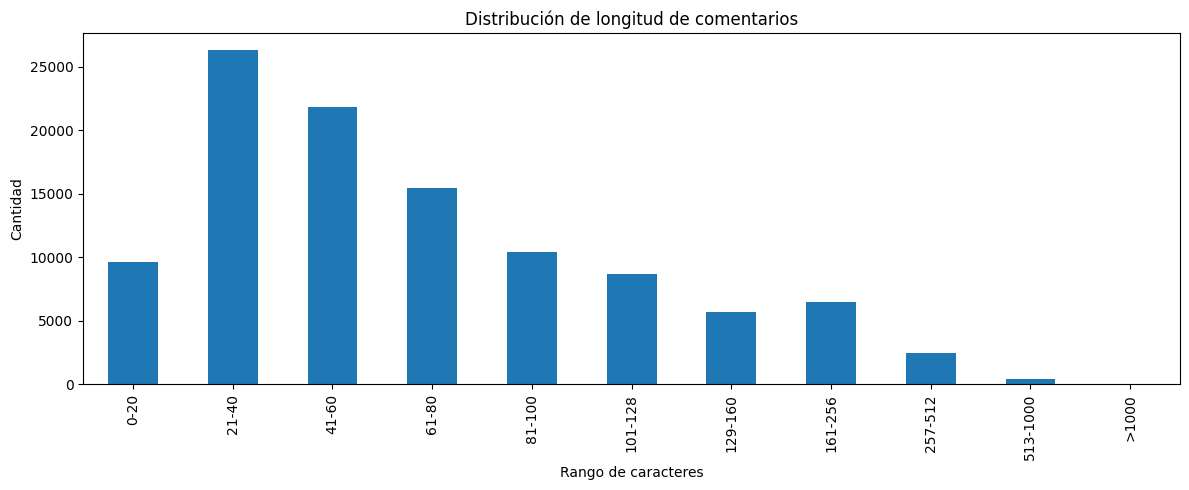

In [ ]:
df_clean['text_length'] = df_clean['text'].str.len()
print(df_clean['text_length'].describe())

bins = [0, 20, 40, 60, 80, 100, 128, 160, 256, 512, 1000, float('inf')]
labels = ['0-20','21-40','41-60','61-80','81-100','101-128','129-160','161-256','257-512','513-1000','>1000']
df_clean['length_range'] = pd.cut(df_clean['text_length'], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(12, 5))
df_clean['length_range'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Distribución de longitud de comentarios')
ax.set_xlabel('Rango de caracteres'); ax.set_ylabel('Cantidad')
plt.tight_layout(); plt.show()

In [ ]:
comments_per_video = df_clean.groupby('video_id').size().sort_values(ascending=False)
print("Comentarios por video/evento:")
print(comments_per_video.describe())

df_clean['year'] = df_clean['created_at'].dt.year
print("\nComentarios por año:")
print(df_clean['year'].value_counts().sort_index())

Comentarios por video/evento:
count     178.000000
mean      604.286517
std       389.996280
min        16.000000
25%       174.250000
50%       732.500000
75%       989.000000
max      1000.000000
dtype: float64

Comentarios por año:
year
2022    39463
2023    20621
2024    10612
2025    19987
2026    16880
Name: count, dtype: int64


## 4. Taxonomía de emociones

## 5. Muestra para etiquetado manual

In [ ]:
from sklearn.model_selection import train_test_split

TAMANO_GOLD = 600

conteo_video = df_clean['video_id'].value_counts()
df_clean['video_id_estrato'] = df_clean['video_id'].where(
    df_clean['video_id'].isin(conteo_video[conteo_video >= 5].index), 'otros'
)

df_pool, df_gold = train_test_split(
    df_clean,
    test_size=TAMANO_GOLD,
    stratify=df_clean['video_id_estrato'],
    random_state=SEED,
)

print(f"Pool para anotación asistida / entrenamiento: {len(df_pool):,}")
print(f"Gold set reservado para anotación manual: {len(df_gold):,}")

Pool para anotación asistida / entrenamiento: 106,963
Gold set reservado para anotación manual: 600


## 6. Guardado de artefactos

In [ ]:
columnas_finales = ['comment_id', 'video_id', 'created_at', 'year', 'author', 'likes', 'reply_count', 'text', 'text_length']

df_pool[columnas_finales].to_csv(f'{RUTA_SALIDA}/pool_comentarios_limpios.csv', index=False)
EMOCIONES = ['alegria', 'tristeza', 'enojo', 'miedo', 'sorpresa', 'burla', 'neutral']
df_gold[columnas_finales].assign(label='').to_csv(f'{RUTA_SALIDA}/gold_set_para_anotar.csv', index=False)
print('Valores permitidos para la columna label:', EMOCIONES)

resumen = {
    'total_crudo': len(df_raw),
    'total_limpio': len(df_clean),
    'pool_size': len(df_pool),
    'gold_size': len(df_gold),
    'semilla': SEED,
    'fecha_generacion': pd.Timestamp.now().isoformat(),
}
with open(f'{RUTA_SALIDA}/resumen_preparacion.json', 'w', encoding='utf-8') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print("Guardado completo:")
for k, v in resumen.items():
    print(f"  {k}: {v}")

Valores permitidos para la columna label: ['alegria', 'tristeza', 'enojo', 'miedo', 'sorpresa', 'burla', 'neutral']
Guardado completo:
  total_crudo: 108742
  total_limpio: 107563
  pool_size: 106963
  gold_size: 600
  semilla: 42
  fecha_generacion: 2026-08-30T04:53:49.974716
